<a href="https://colab.research.google.com/github/danhhuit/deep_learning_practice/blob/main/Labs03_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

In [3]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


In [4]:
num_classes = 10
input_shape = (28, 28, 1)
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes: ', len(np.unique(y_train)))
print('Classes: ', np.unique(y_train))
print(y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes:  10
Classes:  [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


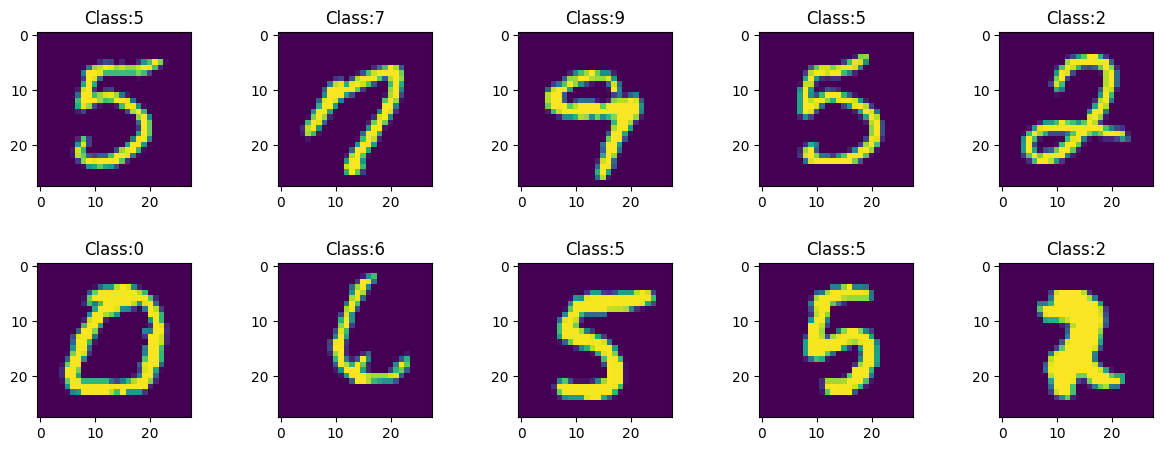

In [5]:
fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [6]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)


model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation="softmax"))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 22s 139ms/step - accuracy: 0.8477 - loss: 0.5623 - val_accuracy: 0.9385 - val_loss: 0.2036
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - accuracy: 0.9598 - loss: 0.1381 - val_accuracy: 0.9605 - val_loss: 0.1396
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - accuracy: 0.9704 - loss: 0.0957 - val_accuracy: 0.9655 - val_loss: 0.1090
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step - accuracy: 0.9784 - loss: 0.0709 - val_accuracy: 0.9765 - val_loss: 0.0796
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - accuracy: 0.9818 - loss: 0.0579 - val_accuracy: 0.9735 - val_loss: 0.0817
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - accuracy: 0.9848 - loss: 0.0492 - val_accuracy: 0.9775 - val_loss: 0.0779
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.9871 - loss: 0.0416 - val_accuracy: 0.9790 - val_loss: 0.0801
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - accuracy: 0.9887 - loss: 0.0349

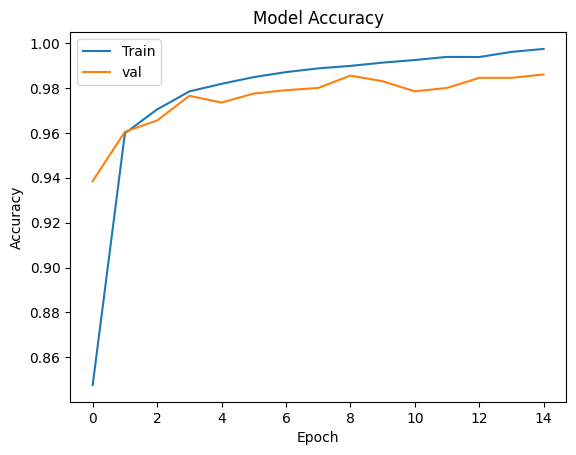

In [8]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'val'], loc='upper left')
plt.show()

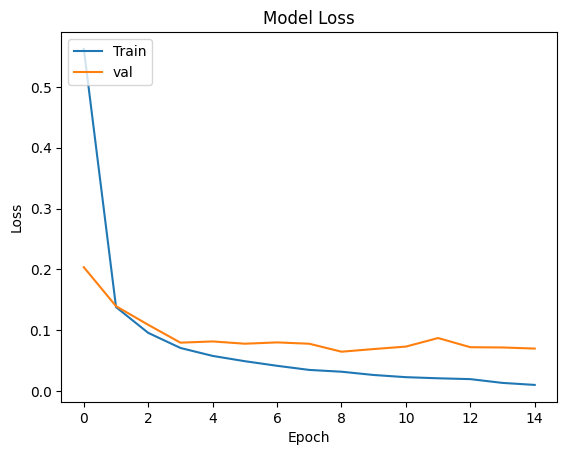

In [9]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'val'], loc='upper left')
plt.show()

In [10]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 2s - 7ms/step - accuracy: 0.9821 - loss: 0.0601
Test loss: 0.06011771783232689
Test accuracy: 0.9820982217788696


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
[[6.11355304e-08 3.65221167e-05 9.99963403e-01 2.58481864e-11
  1.34101325e-20 9.42433103e-16 9.40111633e-09 8.61084316e-19
  9.98896521e-11 2.35844864e-21]]
2 2


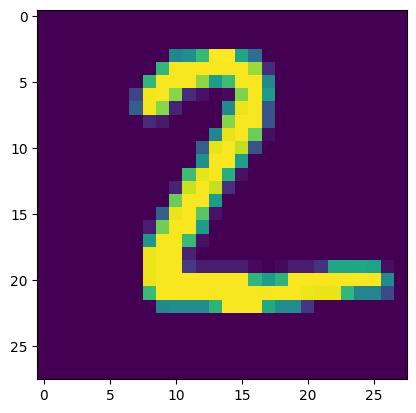

In [11]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))

plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
[[7.4946271e-08 9.9995971e-01 1.8680857e-05 8.6902560e-08 9.5755968e-06
  1.0406688e-07 1.2979383e-06 4.8645843e-06 5.4419693e-06 1.8096912e-08]]
1 1


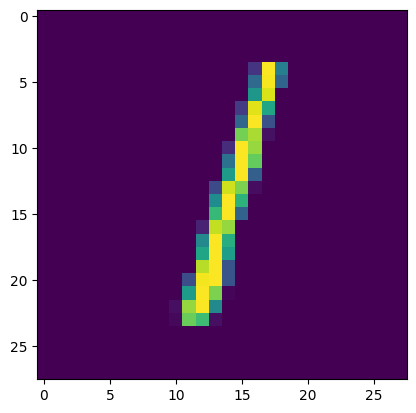

In [12]:
model.save_weights('cnn.weights.h5')
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.load_weights('cnn.weights.h5')
predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))

plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()